 M/M/1 Queue Simulation 
Mean Interarrival Time : 2.0
Mean Service Time      : 1.5
Number of Customers    : 1000
Average Delay in Queue : 4.788
Average Number in Queue: 2.515
Server Utilization     : 0.768
Time Simulation Ended  : 1905.946


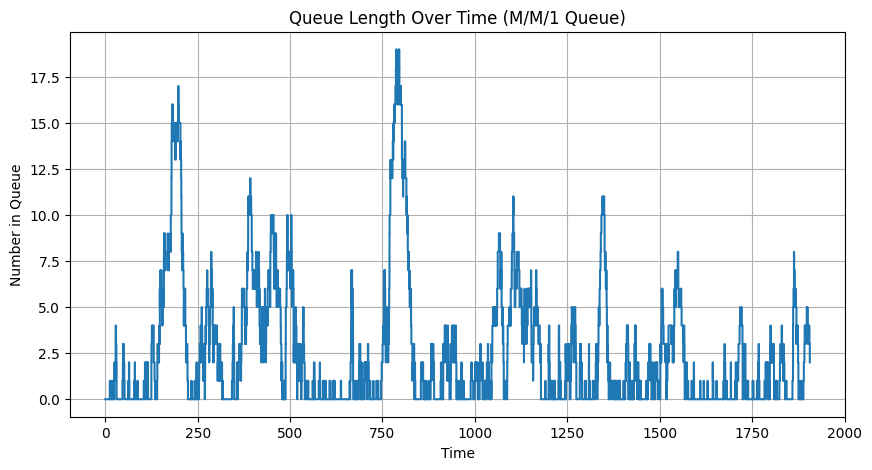

In [3]:
import numpy as np
import matplotlib.pyplot as plt


MEAN_INTERARRIVAL = 2.0      
MEAN_SERVICE = 1.5           
N_CUSTOMERS = 1000           


clock = 0.0
server_busy = False
queue = []

area_Q = 0.0
area_B = 0.0
total_delay = 0.0

customers_departed = 0

next_arrival = np.random.exponential(MEAN_INTERARRIVAL)


next_departure = float("inf")


time_points = [0.0]
queue_lengths = [0]


while customers_departed < N_CUSTOMERS:

    
    next_event_time = min(next_arrival, next_departure)

    
    area_Q += len(queue) * (next_event_time - clock)
    area_B += (1 if server_busy else 0) * (next_event_time - clock)

    
    clock = next_event_time

    
    if next_arrival <= next_departure:

        if not server_busy:
            server_busy = True

            
            service_time = np.random.exponential(MEAN_SERVICE)

            next_departure = clock + service_time

        else:
            
            queue.append(clock)

        
        next_arrival = clock + np.random.exponential(MEAN_INTERARRIVAL)

    
    else:

        customers_departed += 1

        if queue:

            
            arrival_time = queue.pop(0)

            
            delay = clock - arrival_time
            total_delay += delay

            
            service_time = np.random.exponential(MEAN_SERVICE)

            next_departure = clock + service_time

        else:
            server_busy = False
            next_departure = float("inf")

    
    time_points.append(clock)
    queue_lengths.append(len(queue))


avg_delay = total_delay / N_CUSTOMERS
avg_queue = area_Q / clock
utilization = area_B / clock
end_time = clock


print(" M/M/1 Queue Simulation ")
print("Mean Interarrival Time :", MEAN_INTERARRIVAL)
print("Mean Service Time      :", MEAN_SERVICE)
print("Number of Customers    :", N_CUSTOMERS)
print("Average Delay in Queue :", round(avg_delay, 3))
print("Average Number in Queue:", round(avg_queue, 3))
print("Server Utilization     :", round(utilization, 3))
print("Time Simulation Ended  :", round(end_time, 3))


plt.figure(figsize=(10,5))
plt.step(time_points, queue_lengths, where="post")
plt.xlabel("Time")
plt.ylabel("Number in Queue")
plt.title("Queue Length Over Time (M/M/1 Queue)")
plt.grid(True)
plt.show()